In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

data_dir = os.path.join(os.getcwd(), '..', 'data')
scripts_dir = os.path.join(os.getcwd(), '..', 'scripts')

# Load processed data
final_wins = pd.read_csv(os.path.join(data_dir, 'Processed_Historical_Team_Wins_Data.csv'))
team_2026  = pd.read_csv(os.path.join(data_dir, 'Processed_2026_Team_Data.csv'))
image_dir=os.path.join(os.getcwd(), '..', 'images')
print(f"Training data shape:   {final_wins.shape}")
print(f"2026 inference shape:  {team_2026.shape}")
print(f"Years in training:     {sorted(final_wins['Year'].unique())}")
print(f"Teams in 2026:         {team_2026['TEAM'].nunique()}")

Training data shape:   (894, 66)
2026 inference shape:  (29, 63)
Years in training:     [1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
Teams in 2026:         29


# Temporal Trend Analysis of Team Statistics

## Overview

Before modeling, we examined how each feature changes over time. The goal is to identify statistics with strong temporal trends that may need to be detrended — otherwise the model could learn year-over-year shifts in baseball norms rather than true signal about team quality.

We also checked for zero-variance columns within individual years, which can indicate data quality issues such as missing or imputed values.

---

## Step 1: Zero-Variance Check (Data Quality)

For each year, we computed the variance of each feature across all teams. A variance of exactly `0.0` means every team had the **same value** for that statistic in that year — a strong signal of missing or placeholder data.

### Findings

| Year | Feature | Variance |
|------|---------|----------|
| 1995 | `SV_pct` | 0.0 |
| 1996 | `SV_pct` | 0.0 |
| 1997 | `SV_pct` | 0.0 |
| 1998 | `SV_pct` | 0.0 |

**Interpretation:** `SV_pct` (save percentage) had zero variance for the first four years in the dataset (1995–1998), with all teams recording a value of `1.0`. This is almost certainly a data issue — either the field was not tracked in those early years and was filled with a default value, or it was unavailable from the source. A constant value of `1.0` across all teams is not a realistic statistic.

**Action:** Rather than dropping `SV_pct` entirely, a binary flag (e.g. `is_pre_1999`) was created to let the model distinguish records where `SV_pct` is a placeholder from those where it reflects real data.

---

## Step 2: Temporal Correlation (Spearman)

We computed the year-over-year mean of each feature (averaging across all teams per year) and then calculated the **Spearman correlation** between that annual mean and the calendar year. This measures whether a statistic has been trending systematically upward or downward over time across the league.

### Results

| Feature | Spearman ρ (with Year) | Direction | Strength |
|---------|------------------------|-----------|----------|
| `fielding_pct` | +0.938 | ↑ Increasing | Very Strong |
| `SO` | +0.912 | ↑ Increasing | Very Strong |
| `SO_pitch` | +0.912 | ↑ Increasing | Very Strong |
| `P_strikeoutsPer9Inn` | +0.919 | ↑ Increasing | Very Strong |
| `P_strikeoutWalkRatio` | +0.932 | ↑ Increasing | Very Strong |
| `stolenBasePercentage` | +0.822 | ↑ Increasing | Strong |
| `HR` | +0.329 | ↑ Increasing | Weak |
| `P_homeRunsPer9` | +0.304 | ↑ Increasing | Weak |
| `errors` | −0.943 | ↓ Decreasing | Very Strong |
| `AVG` | −0.908 | ↓ Decreasing | Very Strong |
| `AVG_pitch` | −0.908 | ↓ Decreasing | Very Strong |
| `P_hitsPer9Inn` | −0.895 | ↓ Decreasing | Very Strong |
| `OBP` | −0.874 | ↓ Decreasing | Very Strong |
| `WHIP_pitch` | −0.869 | ↓ Decreasing | Very Strong |
| `caughtStealingPercentage` | −0.822 | ↓ Decreasing | Strong |
| `OPS` | −0.718 | ↓ Decreasing | Strong |
| `P_walksPer9Inn` | −0.657 | ↓ Decreasing | Moderate |
| `SV_pct` | −0.623 | ↓ Decreasing | Moderate |
| `ERA_pitch` | −0.604 | ↓ Decreasing | Moderate |
| `BB` | −0.586 | ↓ Decreasing | Moderate |
| `BB_pitch` | −0.586 | ↓ Decreasing | Moderate |
| `SLG` | −0.560 | ↓ Decreasing | Moderate |
| `SB` | −0.318 | ↓ Decreasing | Weak |

> Strength thresholds: |ρ| ≥ 0.8 = Very Strong, 0.6–0.8 = Strong, 0.4–0.6 = Moderate, < 0.4 = Weak

---

## Key Takeaways

### Features with Very Strong Temporal Trends (|ρ| ≥ 0.8)

These statistics reflect **league-wide evolution** over time as much as team quality. Without detrending, a model may learn "it is a recent year" rather than "this team is good."

- **Strikeout-related stats** (`SO`, `SO_pitch`, `P_strikeoutsPer9Inn`, `P_strikeoutWalkRatio`) have all risen sharply — consistent with the well-documented strikeout era in modern baseball.
- **Batting average** (`AVG`, `AVG_pitch`, `P_hitsPer9Inn`) has declined steadily, consistent with league-wide trends.
- **Fielding percentage** has improved and **errors** have declined as expected over time.
- **`caughtStealingPercentage` / `stolenBasePercentage`** move in exactly opposite directions (±0.822), confirming they are inverses — only one should be retained.

### Features with Weak Temporal Trends (|ρ| < 0.4)

`HR`, `P_homeRunsPer9`, and `SB` show little systematic trend and are less likely to require detrending.

---

## Recommended Actions

1. **Detrend or normalize by year** for all features with |ρ| ≥ 0.6 (z-score within each year is the simplest approach).
2. **Use the `is_pre_1999` flag** to handle the `SV_pct` placeholder era rather than dropping the column outright.
3. **Remove one of** `caughtStealingPercentage` or `stolenBasePercentage` — they carry identical information with opposite signs.

In [15]:
features = [
    'fielding_pct', 'HR', 'BB', 'SO', 'SB', 'AVG', 'OBP', 'SLG', 'OPS', 'errors',
    'ERA_pitch', 'caughtStealingPercentage', 'stolenBasePercentage',
    'SV_pct', 'BB_pitch', 'SO_pitch', 'WHIP_pitch', 'AVG_pitch',
    'P_strikeoutsPer9Inn', 'P_walksPer9Inn', 'P_hitsPer9Inn',
    'P_homeRunsPer9', 'P_strikeoutWalkRatio'
]
years=final_wins['Year'].unique()

print('Years with no variance')
for year in years:
    data=final_wins[final_wins['Year']==year]
    for col in features:
        var=data[col].var()
        if var==0.0:
            print(f"\t{year}: {col}: {var}")
grouped_by_year=final_wins.groupby('Year').agg({c:'mean' for c in features}).reset_index()
print('\nSpearman Correlation With Year')
print()
for col in features:
    corr=grouped_by_year[[col,'Year']].corr('spearman')
    print(f"\t{col}: {corr.iloc[1][col]}")

Years with no variance
	1995: SV_pct: 0.0
	1996: SV_pct: 0.0
	1997: SV_pct: 0.0
	1998: SV_pct: 0.0

Spearman Correlation With Year

	fielding_pct: 0.9383622840235156
	HR: 0.328587319243604
	BB: -0.5862068965517241
	SO: 0.9123470522803114
	SB: -0.31835372636262516
	AVG: -0.9082211648146042
	OBP: -0.8736373748609566
	SLG: -0.5599555061179088
	OPS: -0.7179087875417131
	errors: -0.9426028921023359
	ERA_pitch: -0.6044493882091212
	caughtStealingPercentage: -0.821579532814238
	stolenBasePercentage: 0.821579532814238
	SV_pct: -0.6233856871902176
	BB_pitch: -0.5862068965517241
	SO_pitch: 0.9123470522803114
	WHIP_pitch: -0.868617204173497
	AVG_pitch: -0.9078976640711902
	P_strikeoutsPer9Inn: 0.9194660734149055
	P_walksPer9Inn: -0.6569521690767519
	P_hitsPer9Inn: -0.8945494994438264
	P_homeRunsPer9: 0.303670745272525
	P_strikeoutWalkRatio: 0.932369299221357


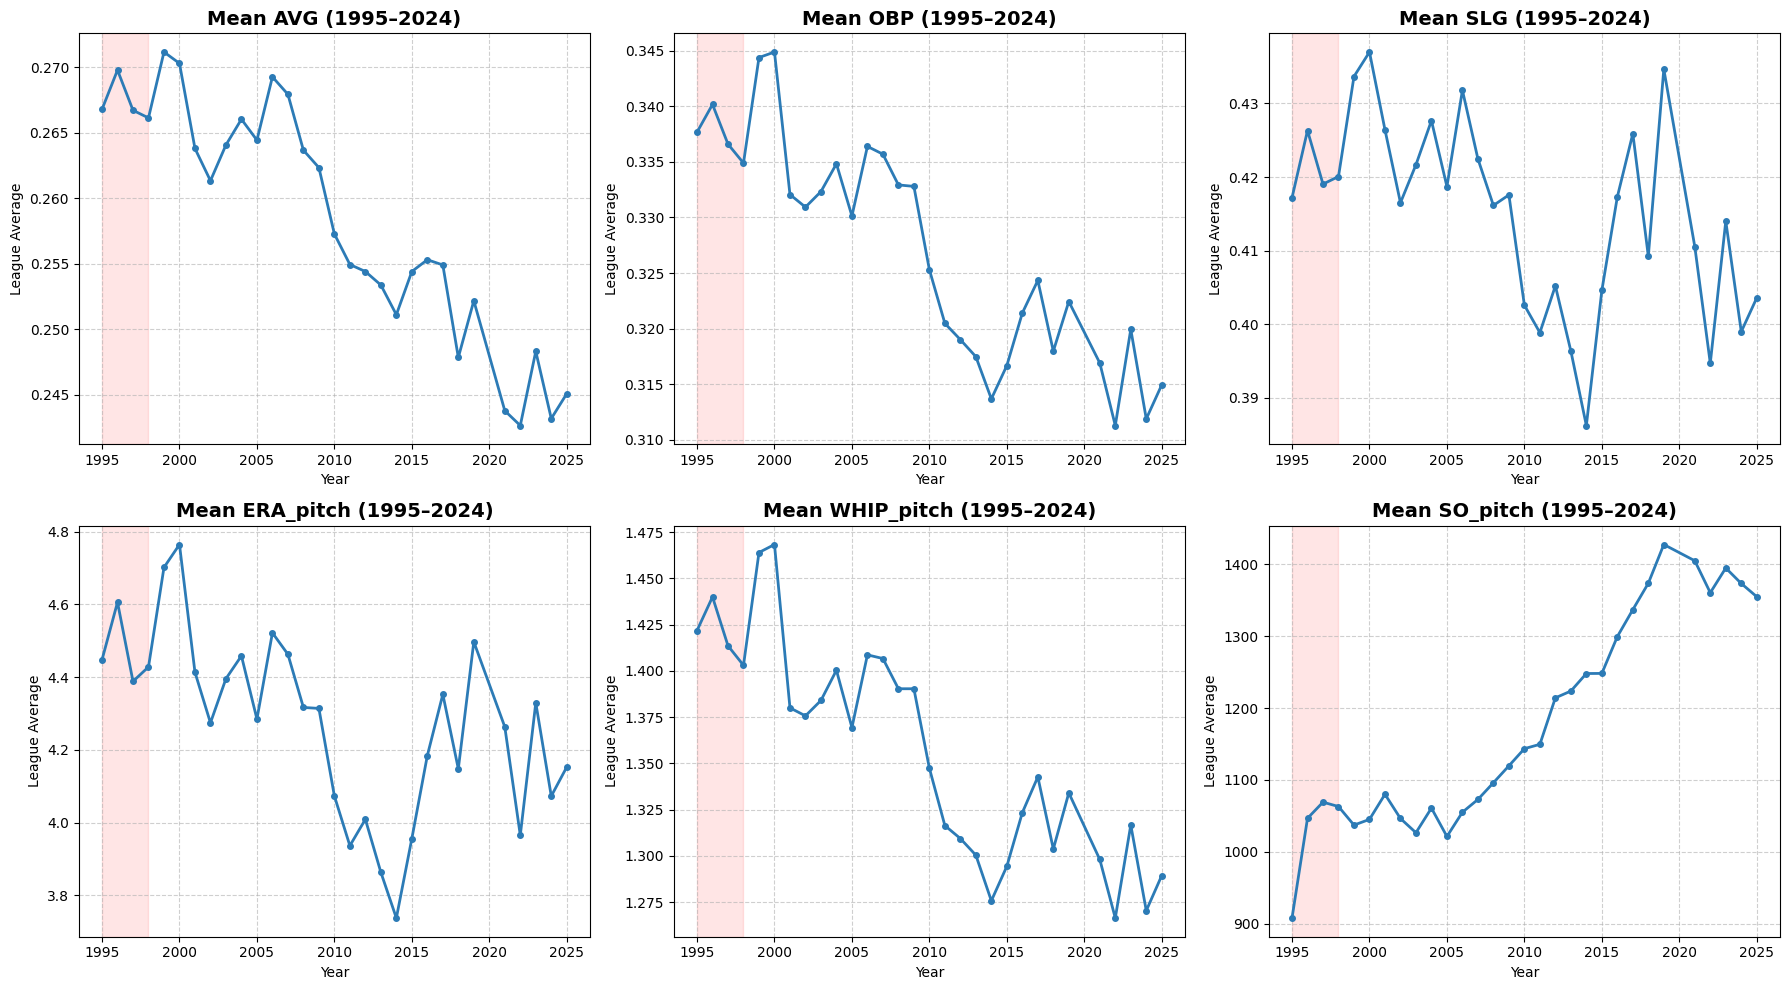

In [3]:
# List of metrics to plot against Year
plot_features = ['AVG', 'OBP', 'SLG', 'ERA_pitch', 'WHIP_pitch', 'SO_pitch']

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_features):
    # Plotting the mean value per year
    axes[i].plot(grouped_by_year['Year'], grouped_by_year[col], 
                 marker='o', markersize=4, linestyle='-', linewidth=2, color='#2c7bb6')
    
    # Titles and Labels
    axes[i].set_title(f'Mean {col} (1995–2024)', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Year', fontsize=10)
    axes[i].set_ylabel('League Average', fontsize=10)
    
    # Adding a grid for better readability
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    # Optional: Highlight the 1995-1998 window if relevant to your investigation
    axes[i].axvspan(1995, 1998, color='red', alpha=0.1, label='Unreliable SV Era')

plt.tight_layout()
plt.savefig('baseball_era_trends.png')

## Step 3: Removing Temporal Trends via Relative Statistics

### Approach

Rather than detrending each feature in isolation (e.g. z-scoring by year), we reframe every statistic as a **relative measure** — how did this team perform compared to its peers in the same year? This naturally removes league-wide temporal drift because both the team value and the reference baseline shift together over time.

For each team-season row, we compute three reference baselines (always excluding the team itself):

| Prefix | Comparison Group |
|--------|-----------------|
| `DivDiff_` | Other teams in the same division and league that year |
| `LeagueDiff_` | All other teams in the same league (AL/NL) that year |
| `mlbDiff_` | All other teams across MLB that year |

---

### Ratio vs. Difference

Not all statistics are on the same scale or have the same interpretation, so two comparison methods are used depending on the nature of the feature:

**Ratio** (`team_stat / league_avg`) — used for continuous rate and counting stats where the baseline is always positive and meaningful. A value of `1.0` means league-average; above `1.0` is better (or worse, depending on the stat).

**Difference** (`team_stat - league_avg`) — used for percentage or bounded stats where a ratio would be less interpretable (e.g. a percentage already near 1.0 would produce ratios clustered tightly around 1).
```python
def _compare(self, row_val, league_val, item):
    if item in self.ratio_stats:
        return row_val / league_val if league_val != 0 else 1.0
    else:
        return row_val - league_val
```

This produces 3 × N new columns (where N = number of features), each expressing team performance relative to a reference group rather than as a raw value.

---

### Why This Removes Temporal Trends

If strikeout rates rise league-wide every year, a raw `SO` feature will appear to grow over time regardless of whether a team is actually improving. By dividing by the league mean, a team that strikeouts at the league-average rate will always register `1.0` — regardless of whether the era is 1995 or 2023. The temporal trend cancels out because it is present in both numerator and denominator.

This is equivalent in spirit to z-scoring by year, but more interpretable: a `LeagueDiff_SO` of `1.15` means the team struck out 15% more batters than the average AL/NL team that season.

---

### Usage
```python
processed_training_data = leagueStats(final_wins, features).applyAgg()
```

The `leagueStats` class accepts an optional `ratio_stats` list to override which features use ratio vs. difference comparison. If not provided, a sensible default is applied covering all standard rate stats, counting stats, and advanced metrics.

In [20]:
class leagueStats:
    def __init__(self, df, features, ratio_stats=None):
        self.df = df
        self.features = features
        self.aggregates = {f: 'mean' for f in features}
        
        # Default ratio stats — meaningful continuous stats that are never zero
        self.ratio_stats = ratio_stats if ratio_stats is not None else [
            'AVG', 'OBP', 'SLG', 'OPS', 'ERA_pitch', 'WHIP_pitch', 'AVG_pitch',
            'R', 'H', 'HR', 'BB', 'SO', 'AB', 'G', 'AB', 'RBI', 'SB', 'CS',
            'W_pitch', 'L_pitch', 'IP_pitch', 'H_pitch', 'R_pitch', 'ER_pitch',
            'HR_pitch', 'BB_pitch', 'SO_pitch', 'HB_pitch',
            'P_strikeoutsPer9Inn', 'P_walksPer9Inn', 'P_hitsPer9Inn',
            'P_homeRunsPer9', 'P_runsScoredPer9', 'P_strikeoutWalkRatio',
            'fielding_pct', 'rangeFactorPerGame', 'rangeFactorPer9Inn',
            'totalBases', 'stolenBasePercentage', 'atBatsPerHomeRun',
        ]

    def _compare(self, row_val, league_val, item):
        """Return ratio if stat is in ratio_stats, else raw difference."""
        if item in self.ratio_stats:
            return row_val / league_val if league_val != 0 else 1.0
        else:
            return row_val - league_val

    def aggregatedStats(self, row, which='Division'):
        L = []
        if which == 'Division':
            df = self.df[
                (self.df['Year'] == row['Year']) &
                (self.df['LEAGUE'] == row['LEAGUE']) &
                (self.df['DIVISION'] == row['DIVISION']) &
                (self.df['TEAM'] != row['TEAM'])
            ]
        elif which == 'League':
            df = self.df[
                (self.df['Year'] == row['Year']) &
                (self.df['LEAGUE'] == row['LEAGUE']) &
                (self.df['TEAM'] != row['TEAM'])
            ]
        else:
            df = self.df[
                (self.df['Year'] == row['Year']) &
                (self.df['TEAM'] != row['TEAM'])
            ]

        for item in self.features:
            av = df[item].mean()
            L.append(self._compare(row[item], av, item))

        return pd.Series(L)

    def applyAgg(self):
        self.df[['DivDiff_'    + item for item in self.features]] = self.df.apply(self.aggregatedStats,                      axis=1)
        self.df[['LeagueDiff_' + item for item in self.features]] = self.df.apply(self.aggregatedStats, which='League', axis=1)
        self.df[['mlbDiff_'    + item for item in self.features]] = self.df.apply(self.aggregatedStats, which='MLB',    axis=1)
        return self.df
processed_training_data=leagueStats(final_wins,features).applyAgg()
processed_training_data

,TEAM,LEAGUE,DIVISION,WINS,Year,G,AB,R,H,2B,...,mlbDiff_SV_pct,mlbDiff_BB_pitch,mlbDiff_SO_pitch,mlbDiff_WHIP_pitch,mlbDiff_AVG_pitch,mlbDiff_P_strikeoutsPer9Inn,mlbDiff_P_walksPer9Inn,mlbDiff_P_hitsPer9Inn,mlbDiff_P_homeRunsPer9,mlbDiff_P_strikeoutWalkRatio
0,Cleveland Indians,AL,C,100,1995,144,5028,840,1461,279,...,0.000000,0.870968,1.020531,0.918701,0.954659,1.009155,0.860844,0.942308,0.912704,1.151912
1,Colorado Rockies,NL,W,77,1995,144,4994,785,1406,259,...,0.000000,1.006993,0.980558,1.071820,1.075338,0.979705,1.005570,1.095065,1.099883,0.956651
2,Chicago White Sox,AL,C,68,1995,145,5060,755,1417,252,...,0.000000,1.222858,0.981698,1.093832,1.032397,0.983932,1.224994,1.043966,1.132100,0.790003
3,Boston Red Sox,AL,E,86,1995,144,4997,791,1399,286,...,0.000000,0.933740,0.977137,0.984119,1.005140,0.973078,0.929364,1.009062,0.862923,1.028161
4,Minnesota Twins,AL,C,56,1995,144,5005,703,1398,270,...,0.000000,1.049902,0.865841,1.101176,1.079248,0.876254,1.062035,1.114916,1.481488,0.810531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,Texas Rangers,AL,W,81,2025,162,5443,684,1275,245,...,-0.069121,0.900174,0.991730,0.912533,0.936535,0.986721,0.895215,0.915499,0.905443,1.091626
890,Chicago White Sox,AL,C,60,2025,162,5377,647,1250,243,...,-0.121261,1.167140,0.947534,1.056806,1.012387,0.961328,1.183687,1.012527,1.017712,0.805052
891,Pittsburgh Pirates,NL,C,71,2025,162,5375,583,1244,245,...,-0.048391,0.920233,0.968854,0.944474,0.961776,0.972881,0.923611,0.948677,0.810039,1.043008
892,Cleveland Guardians,AL,C,88,2025,162,5310,643,1199,243,...,0.055590,1.029020,1.019993,0.976483,0.970200,1.015565,1.024061,0.959070,0.889802,0.981865


## Step 4: Verifying Trend Removal

### Why This Matters for the Model

The goal is to predict team wins (and ultimately division rank) from team statistics using XGBoost. For a model to learn reliable relationships between statistics and winning, a given stat value must mean the **same thing regardless of the year it came from**.

Consider a raw slugging percentage of `.432`. In 1995 that may have been above average; in 2019 (a historically high-offense year) it may have been below average. If we train on raw values, the model is not just learning *"high SLG teams win more"* — it is also learning *"what year does this look like?"*, conflating era effects with team quality. This is a form of data leakage through time.

By expressing every statistic relative to the MLB average in that same year (`mlbDiff_`), a `.432` SLG always becomes a single interpretable number: *this team slugged X% above/below the league average that season*. The signal is now **year-invariant**, which is exactly what the model needs.

---

### Verification: Spearman Correlations After Detrending

We re-ran the Spearman correlation of each feature against `Year` using the `mlbDiff_` relative columns. If detrending was successful, these correlations should collapse toward zero.
```python
grouped_by_year = processed_training_data.groupby('Year').agg(
    {f'mlbDiff_{f}': 'mean' for f in features}
).reset_index()

for col in relative_features:
    corr = grouped_by_year[[col, 'Year']].corr('spearman')
    print(f"\t{col}: {corr.iloc[1][col]}")
```

Features that previously had Spearman correlations as high as ±0.94 with `Year` should now be near zero, confirming the league-wide temporal drift has been absorbed into the baseline.

---

### Plot 1: Full Feature Drift Comparison (Bar Chart)

The first chart shows the Spearman correlation with `Year` for every feature, before and after detrending, sorted by raw correlation magnitude.

- **Red bars** — raw stats, many with correlations above ±0.8
- **Blue bars** — `mlbDiff_` relative stats, collapsed toward zero

This gives a broad view confirming that detrending worked consistently across all 23 features, not just a selected few.

---

### Plot 2: Scatter Grid — Raw vs. Detrended (4 Key Stats)

To illustrate the mechanism visually, four representative statistics are shown as scatter plots across all team-seasons:

| Stat | Raw Trend Direction |
|------|-------------------|
| `SLG` | Declining (offense down in modern era) |
| `OBP` | Declining |
| `SO_pitch` (Strikeouts) | Rising sharply (strikeout era) |
| `ERA_pitch` | Declining |

For each stat, the **left panel** shows the raw values with a linear trend line — a clear slope confirming era bias. The **right panel** shows the `mlbDiff_` version, where:

- The trend line slope approaches zero (no systematic drift)
- A horizontal reference line at `0.0` marks the league average
- Points are now interpretable as *relative team performance*, not absolute era-era values

The dashed trend line slope `m` is annotated on each panel. In the detrended panels, `m` should be near zero across all four statistics.

---

### Summary

| | Raw Stats | `mlbDiff_` Relative Stats |
|---|---|---|
| Temporal drift | Present — model learns era | Removed — model learns quality |
| Interpretability | Absolute value (era-dependent) | Relative to league average |
| Year-invariance | ✗ | ✓ |
| Ready for XGBoost | ✗ | ✓ |

The relative features are now used as inputs to the XGBoost model in place of all raw statistics.

Spearman Correlation Coefficients After Trend Removal
	mlbDiff_fielding_pct: -0.3579532814238042
	mlbDiff_HR: -0.37664071190211346
	mlbDiff_BB: -0.2542825361512792
	mlbDiff_SO: -0.2311457174638487
	mlbDiff_SB: -0.13459399332591768
	mlbDiff_AVG: 0.05050055617352614
	mlbDiff_OBP: -0.19555061179087876
	mlbDiff_SLG: -0.07853170189098999
	mlbDiff_OPS: -0.07675194660734148
	mlbDiff_errors: -0.002731718562481476
	mlbDiff_ERA_pitch: 0.12080088987764183
	mlbDiff_caughtStealingPercentage: -0.12527815174418766
	mlbDiff_stolenBasePercentage: -0.3050055617352614
	mlbDiff_SV_pct: -0.37578168381154975
	mlbDiff_BB_pitch: -0.18665183537263627
	mlbDiff_SO_pitch: -0.6124582869855395
	mlbDiff_WHIP_pitch: 0.27919911012235815
	mlbDiff_AVG_pitch: 0.4540600667408231
	mlbDiff_P_strikeoutsPer9Inn: -0.6293659621802002
	mlbDiff_P_walksPer9Inn: -0.1546162402669633
	mlbDiff_P_hitsPer9Inn: 0.36017797552836484
	mlbDiff_P_homeRunsPer9: -0.3646273637374861
	mlbDiff_P_strikeoutWalkRatio: -0.2738598442714127


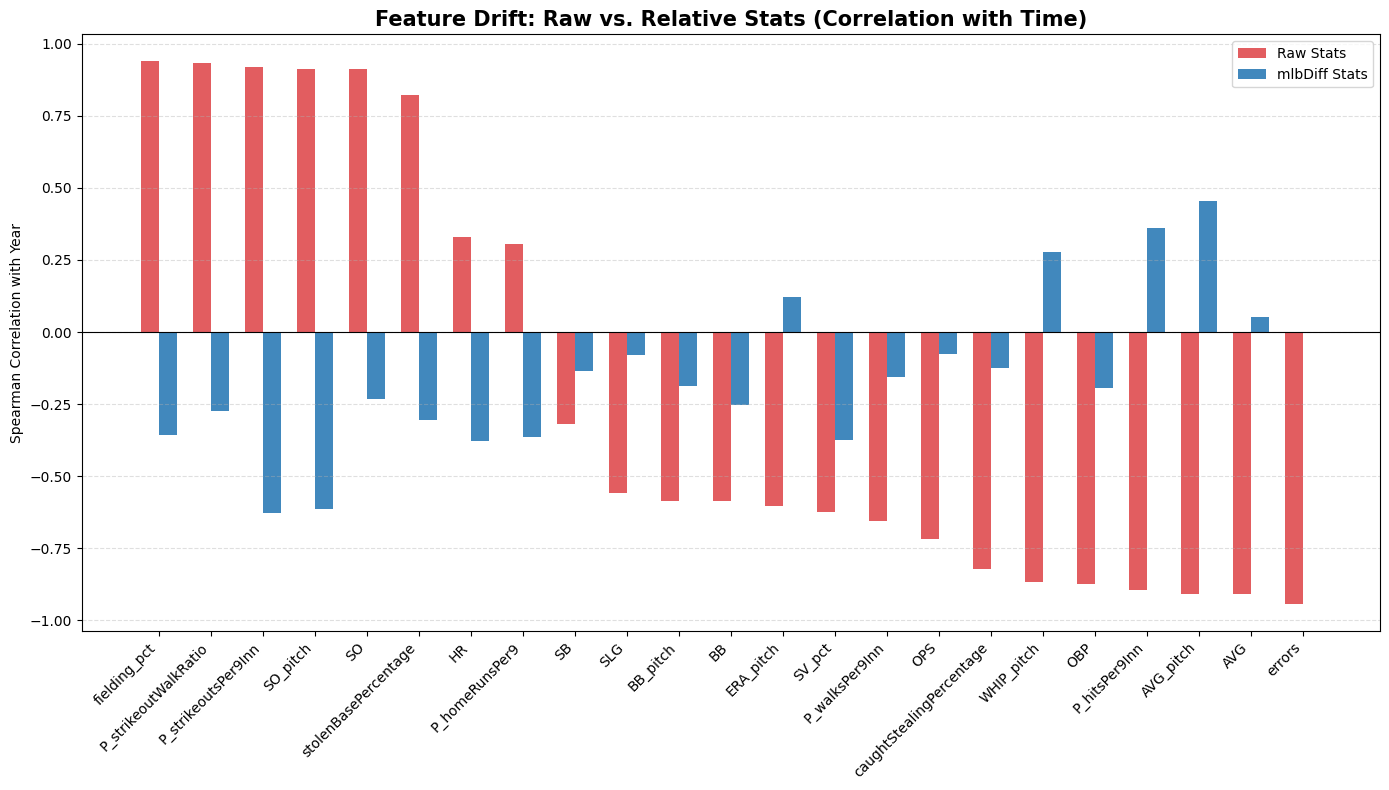

In [21]:
relative_features=[f"mlbDiff_{f}" for f in features]
grouped_by_year=processed_training_data.groupby('Year').agg({c:'mean' for c in relative_features}).reset_index()
print('Spearman Correlation Coefficients After Trend Removal')
for col in relative_features:
    corr=grouped_by_year[[col,'Year']].corr('spearman')
    print(f"\t{col}: {corr.iloc[1][col]}")
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare data for comparison
correlation_data = []

# Grouping raw data for comparison
grouped_raw = final_wins.groupby('Year').agg({f: 'mean' for f in features}).reset_index()
# Grouping relative data (assuming your processed_training_data is ready)
grouped_rel = processed_training_data.groupby('Year').agg({f'mlbDiff_{f}': 'mean' for f in features}).reset_index()

for f in features:
    raw_corr = grouped_raw[[f, 'Year']].corr('spearman').iloc[0, 1]
    rel_corr = grouped_rel[[f'mlbDiff_{f}', 'Year']].corr('spearman').iloc[0, 1]
    correlation_data.append({
        'Feature': f,
        'Raw Correlation': raw_corr,
        'Relative Correlation': rel_corr
    })

df_corr = pd.DataFrame(correlation_data).sort_values(by='Raw Correlation', ascending=False)

# 2. Plotting
plt.figure(figsize=(14, 8))
x = range(len(df_corr))
width = 0.35

plt.bar([i - width/2 for i in x], df_corr['Raw Correlation'], width, label='Raw Stats', color='#d7191c', alpha=0.7)
plt.bar([i + width/2 for i in x], df_corr['Relative Correlation'], width, label='mlbDiff Stats', color='#2c7bb6', alpha=0.9)

# Formatting
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, df_corr['Feature'], rotation=45, ha='right')
plt.ylabel('Spearman Correlation with Year')
plt.title('Feature Drift: Raw vs. Relative Stats (Correlation with Time)', fontsize=15, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(image_dir,'correlation_comparison.png'))

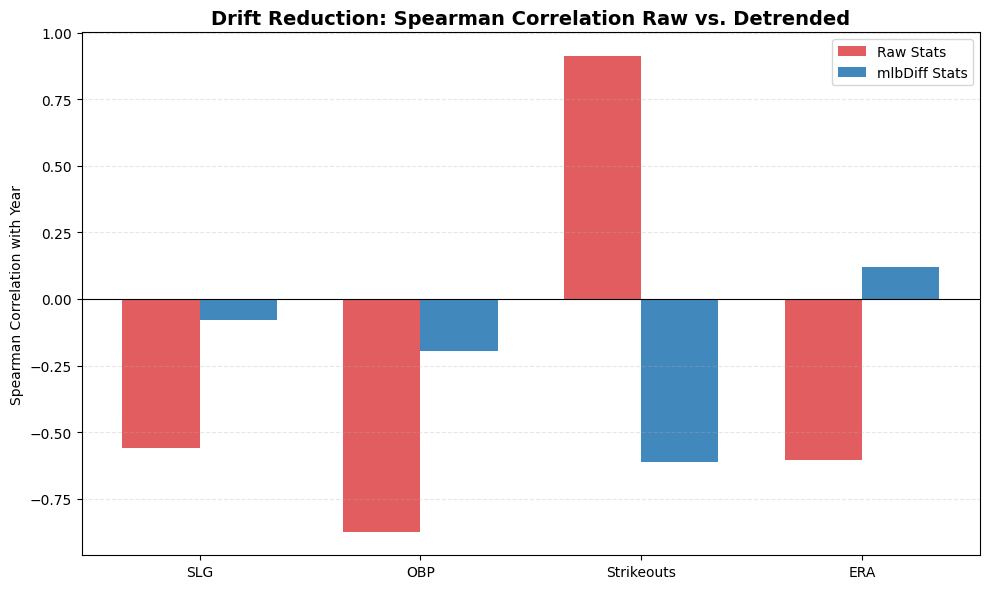

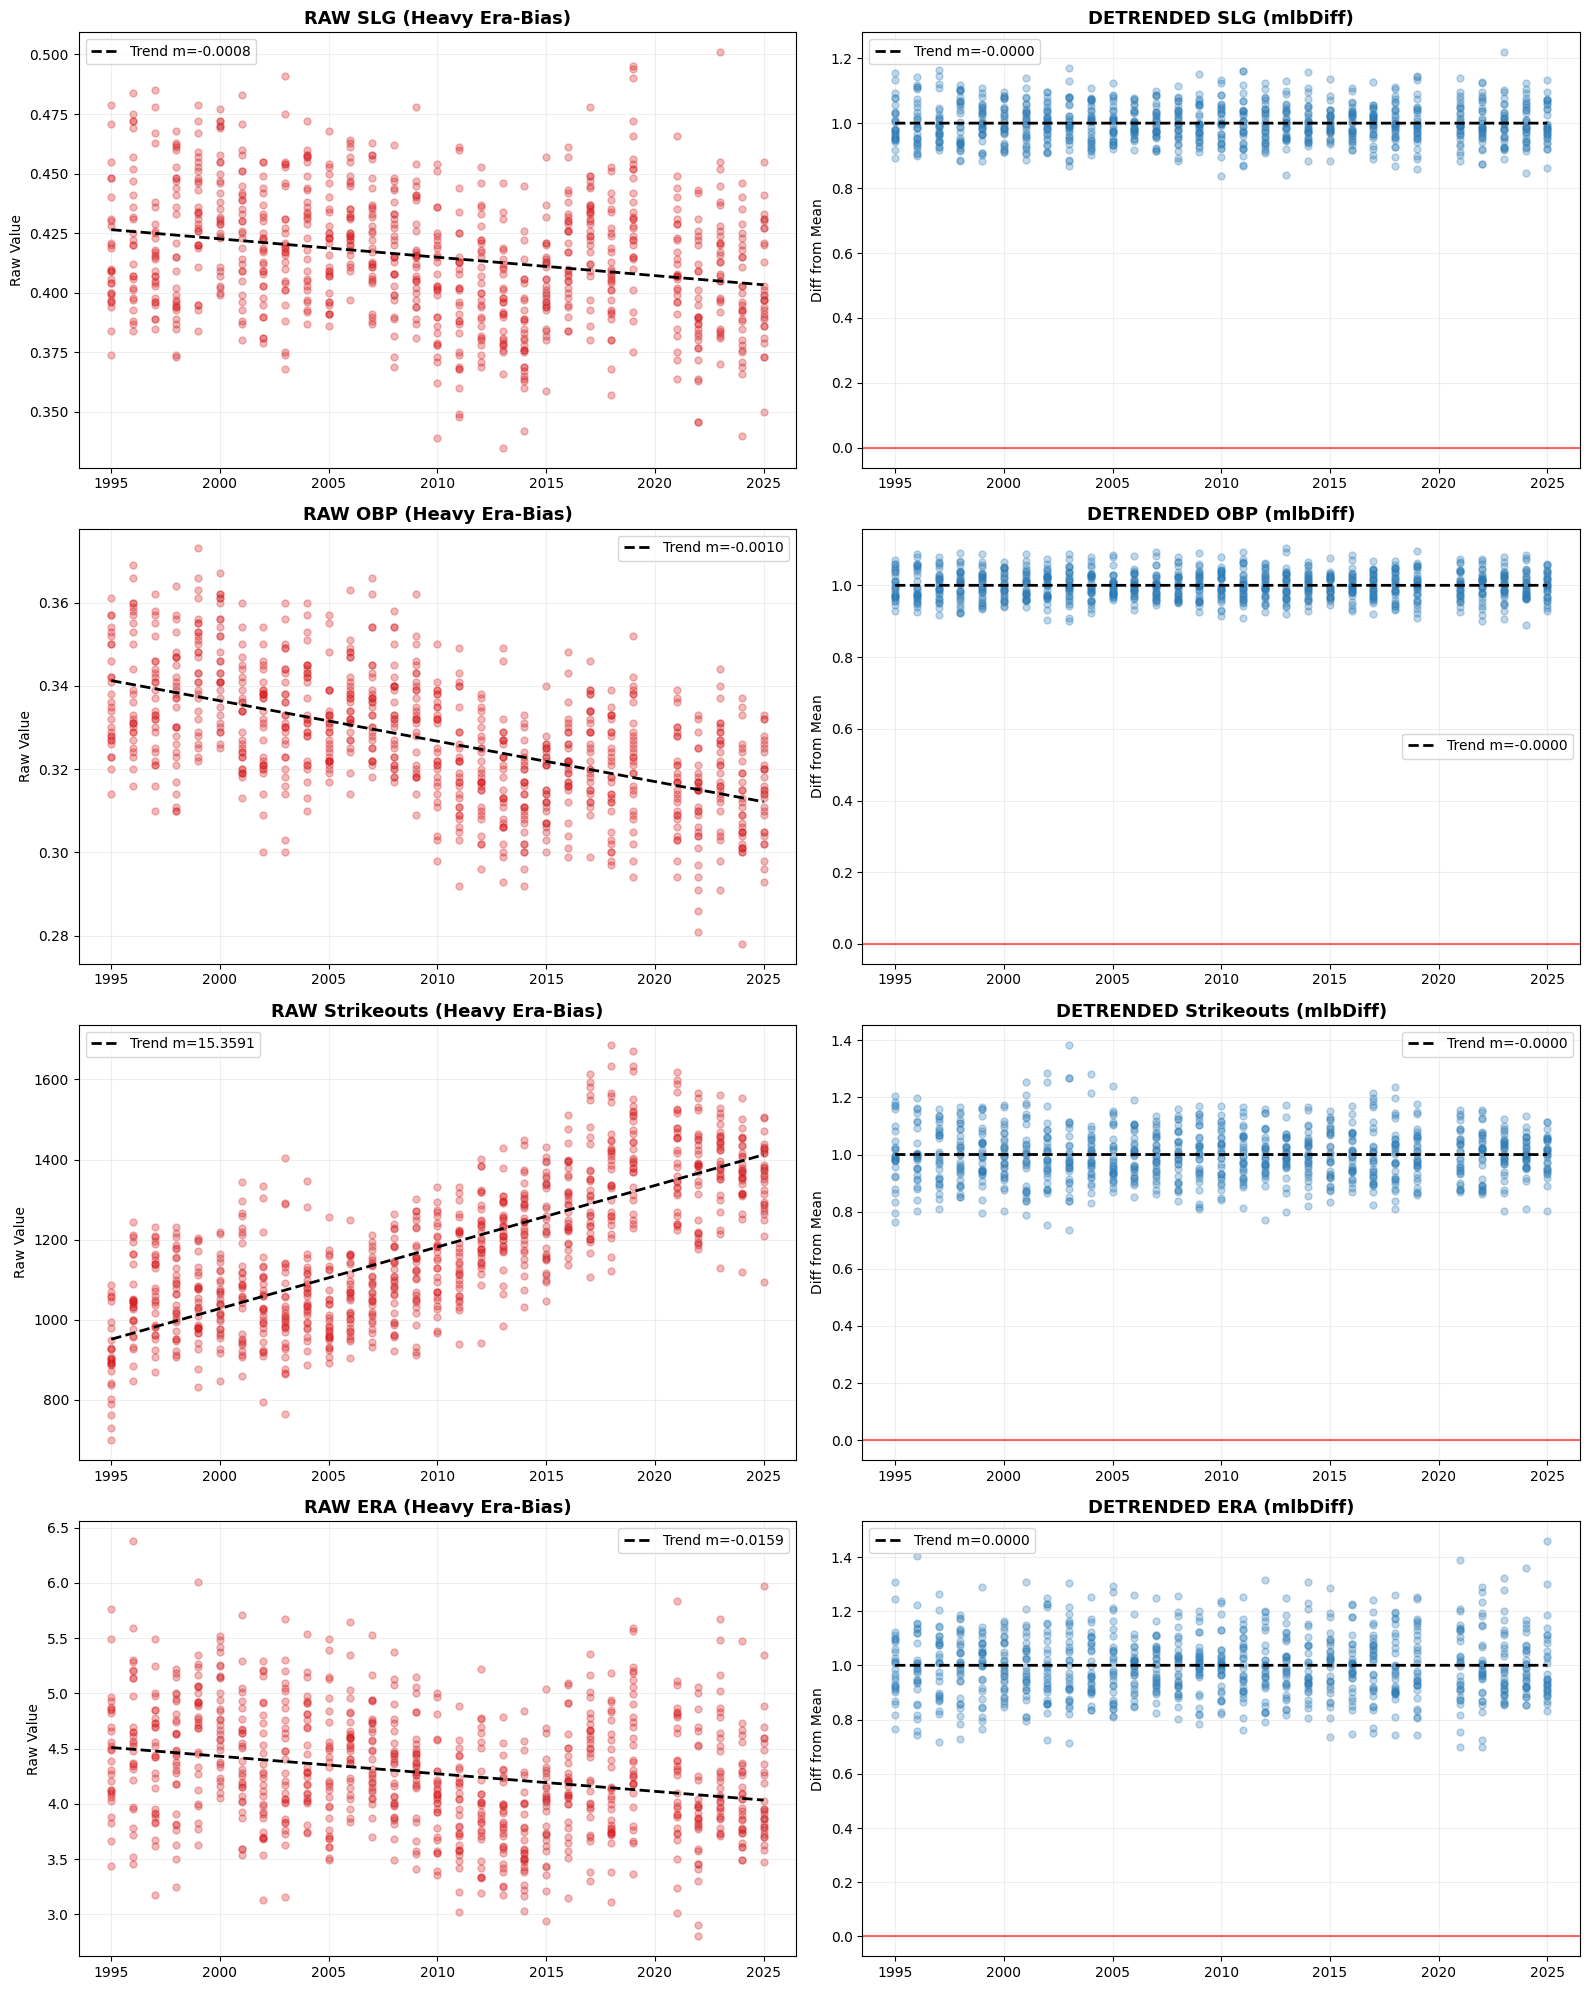

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Mapping your requested metrics to the dataframe columns
target_map = {
    'SLG': ('SLG', 'mlbDiff_SLG'),
    'OBP': ('OBP', 'mlbDiff_OBP'),
    'Strikeouts': ('SO_pitch', 'mlbDiff_SO_pitch'),
    'ERA': ('ERA_pitch', 'mlbDiff_ERA_pitch')
}

features_to_compare = list(target_map.keys())
raw_cols = [v[0] for v in target_map.values()]
rel_cols = [v[1] for v in target_map.values()]

# 1. Calculate correlations for the Bar Chart Comparison
# This replicates your logic to see how much "Year-drift" was removed
grouped_raw = final_wins.groupby('Year').agg({c: 'mean' for c in raw_cols}).reset_index()
grouped_rel = processed_training_data.groupby('Year').agg({c: 'mean' for c in rel_cols}).reset_index()

correlation_results = []
for label, (r_col, m_col) in target_map.items():
    raw_corr = grouped_raw[[r_col, 'Year']].corr('spearman').iloc[0, 1]
    rel_corr = grouped_rel[[m_col, 'Year']].corr('spearman').iloc[0, 1]
    correlation_results.append({
        'Feature': label,
        'Raw Correlation': raw_corr,
        'Relative Correlation': rel_corr
    })

df_corr = pd.DataFrame(correlation_results)

# 2. Plotting the Spearman Comparison (Bar Chart)
plt.figure(figsize=(10, 6))
x = np.arange(len(df_corr))
width = 0.35

plt.bar(x - width/2, df_corr['Raw Correlation'], width, label='Raw Stats', color='#d7191c', alpha=0.7)
plt.bar(x + width/2, df_corr['Relative Correlation'], width, label='mlbDiff Stats', color='#2c7bb6', alpha=0.9)

plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, df_corr['Feature'])
plt.ylabel('Spearman Correlation with Year')
plt.title('Drift Reduction: Spearman Correlation Raw vs. Detrended', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Plotting the Scatter Grid (Visual Detrending)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

for i, label in enumerate(features_to_compare):
    r_col, m_col = target_map[label]
    
    # Left Column: Raw Scatter
    axes[i, 0].scatter(final_wins['Year'], final_wins[r_col], alpha=0.3, color='#d7191c', s=25)
    z1 = np.polyfit(final_wins['Year'], final_wins[r_col], 1)
    p1 = np.poly1d(z1)
    axes[i, 0].plot(final_wins['Year'], p1(final_wins['Year']), "k--", linewidth=2, label=f"Trend m={z1[0]:.4f}")
    axes[i, 0].set_title(f'RAW {label} (Heavy Era-Bias)', fontsize=13, fontweight='bold')
    axes[i, 0].set_ylabel('Raw Value')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.2)

    # Right Column: Detrended Scatter (mlbDiff)
    axes[i, 1].scatter(processed_training_data['Year'], processed_training_data[m_col], alpha=0.3, color='#2c7bb6', s=25)
    z2 = np.polyfit(processed_training_data['Year'], processed_training_data[m_col], 1)
    p2 = np.poly1d(z2)
    axes[i, 1].plot(processed_training_data['Year'], p2(processed_training_data['Year']), "k--", linewidth=2, label=f"Trend m={z2[0]:.4f}")
    axes[i, 1].axhline(0, color='red', linewidth=1.5, alpha=0.6) # League Average
    axes[i, 1].set_title(f'DETRENDED {label} (mlbDiff)', fontsize=13, fontweight='bold')
    axes[i, 1].set_ylabel('Diff from Mean')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(image_dir,'correlation_comparison_trend.png'))
plt.show()